In [1]:
import jones_tensor
import numpy as np
import matplotlib.pyplot as plt

Example: evaluating the Jones for the Trefoil at the point $q = 2$

In [ ]:
trefoil = jones_tensor.MorseLink.from_braid([-1, -1, -1])
jones_tensor.evaluate_jones(2.0, trefoil)

(0.5625+0j)

You can also use the PD notation instead of a braid representative:

In [21]:
trefoil = jones_tensor.MorseLink.from_pd([[1, 4, 2, 5], [3, 6, 4, 1], [5, 2, 6, 3]])
jones_tensor.evaluate_jones(2.0, trefoil)

(0.5625000000000001+0j)

You can evaluate it at multiple points in a batch.
This will be faster than calling `evaluate_jones` for each point individually.

In [ ]:

jones_tensor.evaluate_jones(np.array([1.0, 2.0, 3.0, 4.0]), trefoil)

array([1.        +0.j, 0.5625    +0.j, 0.35802469+0.j, 0.26171875+0.j])

A bigger example - plotting the value of the Jones of $10_{123}$ for a disk in the complex plane:

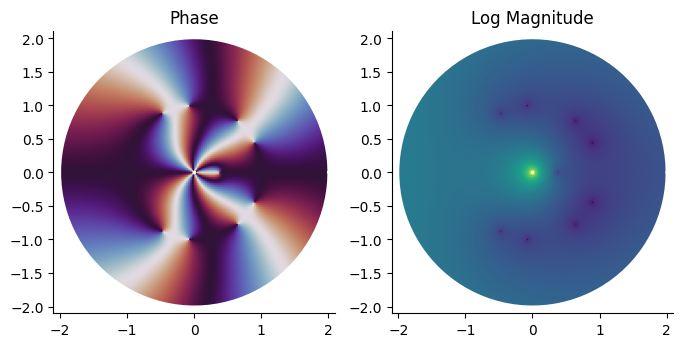

In [ ]:
knot_10_123 = jones_tensor.MorseLink.from_braid([-1, 2, -1, 2, -1, 2, -1, 2, -1, 2])
rmin = 0.01
rmax = 2.0

# Create values of q in a grid:
x = np.linspace(-rmax, rmax, 400)
y = np.linspace(-rmax, rmax, 400)
x, y = np.meshgrid(x, y)
q = x + 1j * y
r = np.sqrt(x*x + y*y)
mask = (r >= rmin) & (r <= rmax)

# Calculate the Jones (it's helpful to increase batchsize here since the knot is small and there are many evaluation points)
jones = np.nan * np.ones_like(x, dtype=complex)
jones[mask] = jones_tensor.evaluate_jones(q[mask], knot_10_123, batchsize=512)

# Plot the phase and log of magnitude:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), subplot_kw={'aspect': 'equal'})
t = np.linspace(0, 2*np.pi, 100)

ax1.imshow(np.angle(jones), cmap='twilight', vmin=-np.pi, vmax=np.pi, interpolation='nearest', extent=[-2, 2, -2, 2])
ax1.plot(rmin*np.cos(t), rmin*np.sin(t), '-', color='white')
ax1.plot(rmax*np.cos(t), rmax*np.sin(t), '-', color='white')
ax1.set_xlim(-rmax-0.1, rmax+0.1)
ax1.set_ylim(-rmax-0.1, rmax+0.1)
ax1.set_title("Phase")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.imshow(np.abs(jones), cmap='viridis', norm='log', interpolation='nearest', extent=[-2, 2, -2, 2])
ax2.plot(rmin*np.cos(t), rmin*np.sin(t), '-', color='white')
ax2.plot(rmax*np.cos(t), rmax*np.sin(t), '-', color='white')
ax2.set_xlim(-rmax-0.1, rmax+0.1)
ax2.set_ylim(-rmax-0.1, rmax+0.1)
ax2.set_title("Log Magnitude")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)